# Bước 4 — EFA (Exploratory Factor Analysis)
**Input:** `data_sau_cronbach.csv`  
**Output:** Bảng factor loading, scree plot, kết luận số nhân tố

---
### Tiêu chí đánh giá
| Chỉ số | Ngưỡng chấp nhận |
|--------|------------------|
| KMO | ≥ 0.6 (tốt ≥ 0.8) |
| Bartlett's Test | p < 0.05 |
| Eigenvalue | ≥ 1.0 để giữ nhân tố |
| Factor Loading | ≥ 0.5 (lý tưởng ≥ 0.6) |
| Communality | ≥ 0.5 |
| Cross-loading | Chênh lệch ≥ 0.2 so với loading cao nhất |

In [1]:
!pip install factor_analyzer openpyxl --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from factor_analyzer import FactorAnalyzer
from factor_analyzer.factor_analyzer import calculate_kmo, calculate_bartlett_sphericity
from google.colab import files
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 130
print('Sẵn sàng!')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 1.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Sẵn sàng!


In [2]:
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)
print(f'N = {len(df)}')

Saving data_sach (1).csv to data_sach (1).csv
N = 193


In [3]:
# Định nghĩa nhóm — cập nhật nếu đã loại item ở Bước 3
groups = {
    'EE':  [f'EE{i}'  for i in range(1,6)],
    'PE':  [f'PE{i}'  for i in range(1,6)],
    'SI':  [f'SI{i}'  for i in range(1,6)],
    'FC':  [f'FC{i}'  for i in range(1,6)],
    'RA':  [f'RA{i}'  for i in range(1,6)],
    'ANX': [f'ANX{i}' for i in range(1,6)],
    'BI':  [f'BI{i}'  for i in range(1,6)],
}
likert_cols = [c for cols in groups.values() for c in cols]

# Lọc chỉ lấy cột Likert còn trong df (phòng trường hợp đã loại item)
likert_cols = [c for c in likert_cols if c in df.columns]
df_efa = df[likert_cols].dropna()
print(f'Số biến quan sát đưa vào EFA: {len(likert_cols)}')
print(f'N dùng EFA: {len(df_efa)}')

Số biến quan sát đưa vào EFA: 35
N dùng EFA: 193


---
## 1. Kiểm định KMO & Bartlett

In [4]:
kmo_all, kmo_model = calculate_kmo(df_efa)
chi2, p_val = calculate_bartlett_sphericity(df_efa)

print('=== KMO & BARTLETT TEST ===')
print(f'KMO = {kmo_model:.4f}', end='  →  ')
if   kmo_model >= 0.9: print('Rất tốt (Marvelous) ✅')
elif kmo_model >= 0.8: print('Tốt (Meritorious) ✅')
elif kmo_model >= 0.7: print('Khá (Middling) ✅')
elif kmo_model >= 0.6: print('Chấp nhận được ⚠️')
else:                  print('Không phù hợp EFA ❌')

print(f'Bartlett Chi² = {chi2:.2f},  p = {p_val:.4f}', end='  →  ')
if p_val < 0.05:
    print('Có ý nghĩa thống kê → Ma trận tương quan phù hợp EFA ✅')
else:
    print('KHÔNG có ý nghĩa ❌ — dữ liệu không phù hợp EFA')

=== KMO & BARTLETT TEST ===
KMO = 0.8610  →  Tốt (Meritorious) ✅
Bartlett Chi² = 2828.29,  p = 0.0000  →  Có ý nghĩa thống kê → Ma trận tương quan phù hợp EFA ✅


---
## 2. Scree Plot — xác định số nhân tố

Số nhân tố có eigenvalue > 1: 7

Eigenvalue từng nhân tố:
  F1: 9.0588 ← giữ
  F2: 2.3131 ← giữ
  F3: 2.2778 ← giữ
  F4: 2.1348 ← giữ
  F5: 2.1026 ← giữ
  F6: 1.6946 ← giữ
  F7: 1.4579 ← giữ
  F8: 0.9188
  F9: 0.8728
  F10: 0.8271
  F11: 0.7703
  F12: 0.7426


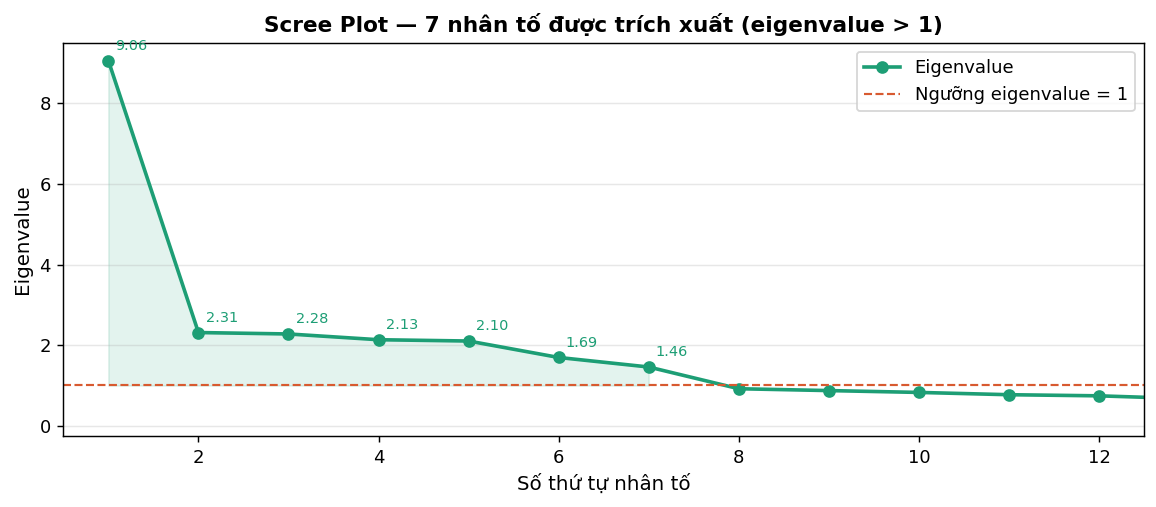


→ Kết luận: Trích 7 nhân tố


In [5]:
# Chạy EFA sơ bộ để lấy eigenvalue
fa_eigen = FactorAnalyzer(n_factors=len(likert_cols), rotation=None)
fa_eigen.fit(df_efa)
ev, v = fa_eigen.get_eigenvalues()

n_factors_eigen1 = sum(ev > 1)
print(f'Số nhân tố có eigenvalue > 1: {n_factors_eigen1}')
print('\nEigenvalue từng nhân tố:')
for i, e in enumerate(ev[:12], 1):
    mark = ' ← giữ' if e > 1 else ''
    print(f'  F{i}: {e:.4f}{mark}')

# Scree plot
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, len(ev)+1), ev, 'o-', color='#1D9E75', linewidth=2, markersize=6, label='Eigenvalue')
ax.axhline(1, color='#D85A30', linestyle='--', linewidth=1.2, label='Ngưỡng eigenvalue = 1')
ax.fill_between(range(1, n_factors_eigen1+1), ev[:n_factors_eigen1], 1,
                alpha=0.12, color='#1D9E75')
ax.set_xlabel('Số thứ tự nhân tố', fontsize=11)
ax.set_ylabel('Eigenvalue', fontsize=11)
ax.set_title(f'Scree Plot — {n_factors_eigen1} nhân tố được trích xuất (eigenvalue > 1)',
             fontweight='bold')
ax.legend(fontsize=10)
ax.set_xlim(0.5, min(12, len(ev)) + 0.5)
ax.grid(axis='y', alpha=0.3)

# Đánh dấu điểm gãy (elbow)
for i, e in enumerate(ev[:n_factors_eigen1], 1):
    ax.annotate(f'{e:.2f}', (i, e), textcoords='offset points',
                xytext=(4, 6), fontsize=8, color='#1D9E75')

plt.tight_layout()
plt.savefig('scree_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\n→ Kết luận: Trích {n_factors_eigen1} nhân tố')

---
## 3. Chạy EFA chính thức (Promax rotation)

In [6]:
# Promax: phù hợp khi các nhân tố có tương quan với nhau (thường gặp trong SEM)
# Nếu muốn Varimax (orthogonal): đổi rotation='varimax'
N_FACTORS = n_factors_eigen1  # Hoặc set thủ công: N_FACTORS = 7

fa = FactorAnalyzer(n_factors=N_FACTORS, rotation='promax', method='ml')
fa.fit(df_efa)

# Factor loadings
loadings = pd.DataFrame(
    fa.loadings_,
    index=likert_cols,
    columns=[f'F{i+1}' for i in range(N_FACTORS)]
)

# Communality
communality = pd.Series(fa.get_communalities(), index=likert_cols, name='Communality')

df_load = loadings.copy()
df_load['Communality'] = communality

# Nhóm lý thuyết của từng item
theory_group = {col: g for g, cols in groups.items() for col in cols if col in likert_cols}
df_load['Nhóm lý thuyết'] = [theory_group.get(i, '?') for i in df_load.index]

# Nhân tố cao nhất mỗi item
factor_cols = [f'F{i+1}' for i in range(N_FACTORS)]
df_load['Factor chính'] = df_load[factor_cols].abs().idxmax(axis=1)
df_load['Loading max']  = df_load[factor_cols].abs().max(axis=1).round(4)

print(f'EFA xong! ({N_FACTORS} nhân tố, Promax rotation)')
print(f'\nVariance explained:')
var_exp = fa.get_factor_variance()
total_var = 0
for i, (ss, prop, cum) in enumerate(zip(*var_exp), 1):
    total_var = cum
    print(f'  F{i}: {prop*100:.2f}%  (cumulative: {cum*100:.2f}%)')
print(f'\nTổng phương sai giải thích: {total_var*100:.2f}%', end='  →  ')
print('Tốt ✅' if total_var >= 0.5 else 'Thấp ⚠️ (cần xem lại)')

EFA xong! (7 nhân tố, Promax rotation)

Variance explained:
  F1: 8.04%  (cumulative: 8.04%)
  F2: 7.38%  (cumulative: 15.42%)
  F3: 7.11%  (cumulative: 22.53%)
  F4: 6.97%  (cumulative: 29.50%)
  F5: 6.86%  (cumulative: 36.36%)
  F6: 6.50%  (cumulative: 42.87%)
  F7: 6.00%  (cumulative: 48.87%)

Tổng phương sai giải thích: 48.87%  →  Thấp ⚠️ (cần xem lại)


---
## 4. Bảng factor loading — kiểm tra hội tụ & phân biệt

In [7]:
THRESHOLD = 0.5  # Ngưỡng loading tối thiểu

print(f'=== BẢNG FACTOR LOADING (ngưỡng hiển thị: |loading| ≥ {THRESHOLD}) ===')
print(f'{"Item":<8} {"Nhóm lý thuyết":<8}', end='')
for f in factor_cols:
    print(f'{f:>8}', end='')
print(f'{"Comm.":>8}  Ghi chú')
print('-' * (28 + 8*N_FACTORS + 20))

items_issue = []
for item in likert_cols:
    row   = df_load.loc[item]
    loads = [row[f] for f in factor_cols]
    comm  = row['Communality']
    group = row['Nhóm lý thuyết']

    # Kiểm tra vấn đề
    notes = []
    max_load = max(abs(l) for l in loads)
    if max_load < THRESHOLD:         notes.append('Loading thấp ⚠️')
    if comm < 0.5:                   notes.append('Communality thấp ⚠️')

    # Cross-loading: item có 2 loading ≥ 0.4 trở lên
    high_loads = [f for f, l in zip(factor_cols, loads) if abs(l) >= 0.4]
    if len(high_loads) > 1:          notes.append(f'Cross-loading ⚠️')

    note_str = ' | '.join(notes)
    if notes: items_issue.append(item)

    print(f'{item:<8} {group:<8}', end='')
    for l in loads:
        marker = f'{l:>7.3f}*' if abs(l) >= THRESHOLD else f'{l:>7.3f} '
        print(marker, end='')
    print(f'{comm:>8.3f}  {note_str}')

print(f'\n(* = loading ≥ {THRESHOLD})')
if items_issue:
    print(f'\n⚠️ Item cần xem lại: {items_issue}')
else:
    print('\n✅ Tất cả item hội tụ tốt!')

=== BẢNG FACTOR LOADING (ngưỡng hiển thị: |loading| ≥ 0.5) ===
Item     Nhóm lý thuyết      F1      F2      F3      F4      F5      F6      F7   Comm.  Ghi chú
--------------------------------------------------------------------------------------------------------
EE1      EE        0.070  -0.064   0.043   0.015  -0.036   0.644*  0.105    0.439  Communality thấp ⚠️
EE2      EE       -0.021   0.119  -0.081   0.120  -0.029   0.549*  0.041    0.339  Communality thấp ⚠️
EE3      EE        0.015  -0.077  -0.018  -0.041   0.072   0.741*  0.004    0.562  
EE4      EE        0.093   0.048   0.050  -0.009  -0.007   0.616* -0.044    0.395  Communality thấp ⚠️
EE5      EE        0.010  -0.021   0.085   0.046   0.115   0.548*  0.013    0.324  Communality thấp ⚠️
PE1      PE        0.766*  0.035   0.052   0.122  -0.068  -0.085  -0.029    0.618  
PE2      PE        0.701*  0.042   0.009  -0.134   0.159   0.129  -0.028    0.553  
PE3      PE        0.685*  0.101   0.101  -0.072   0.036  -0.046  -0.01

---
## 5. Heatmap factor loading

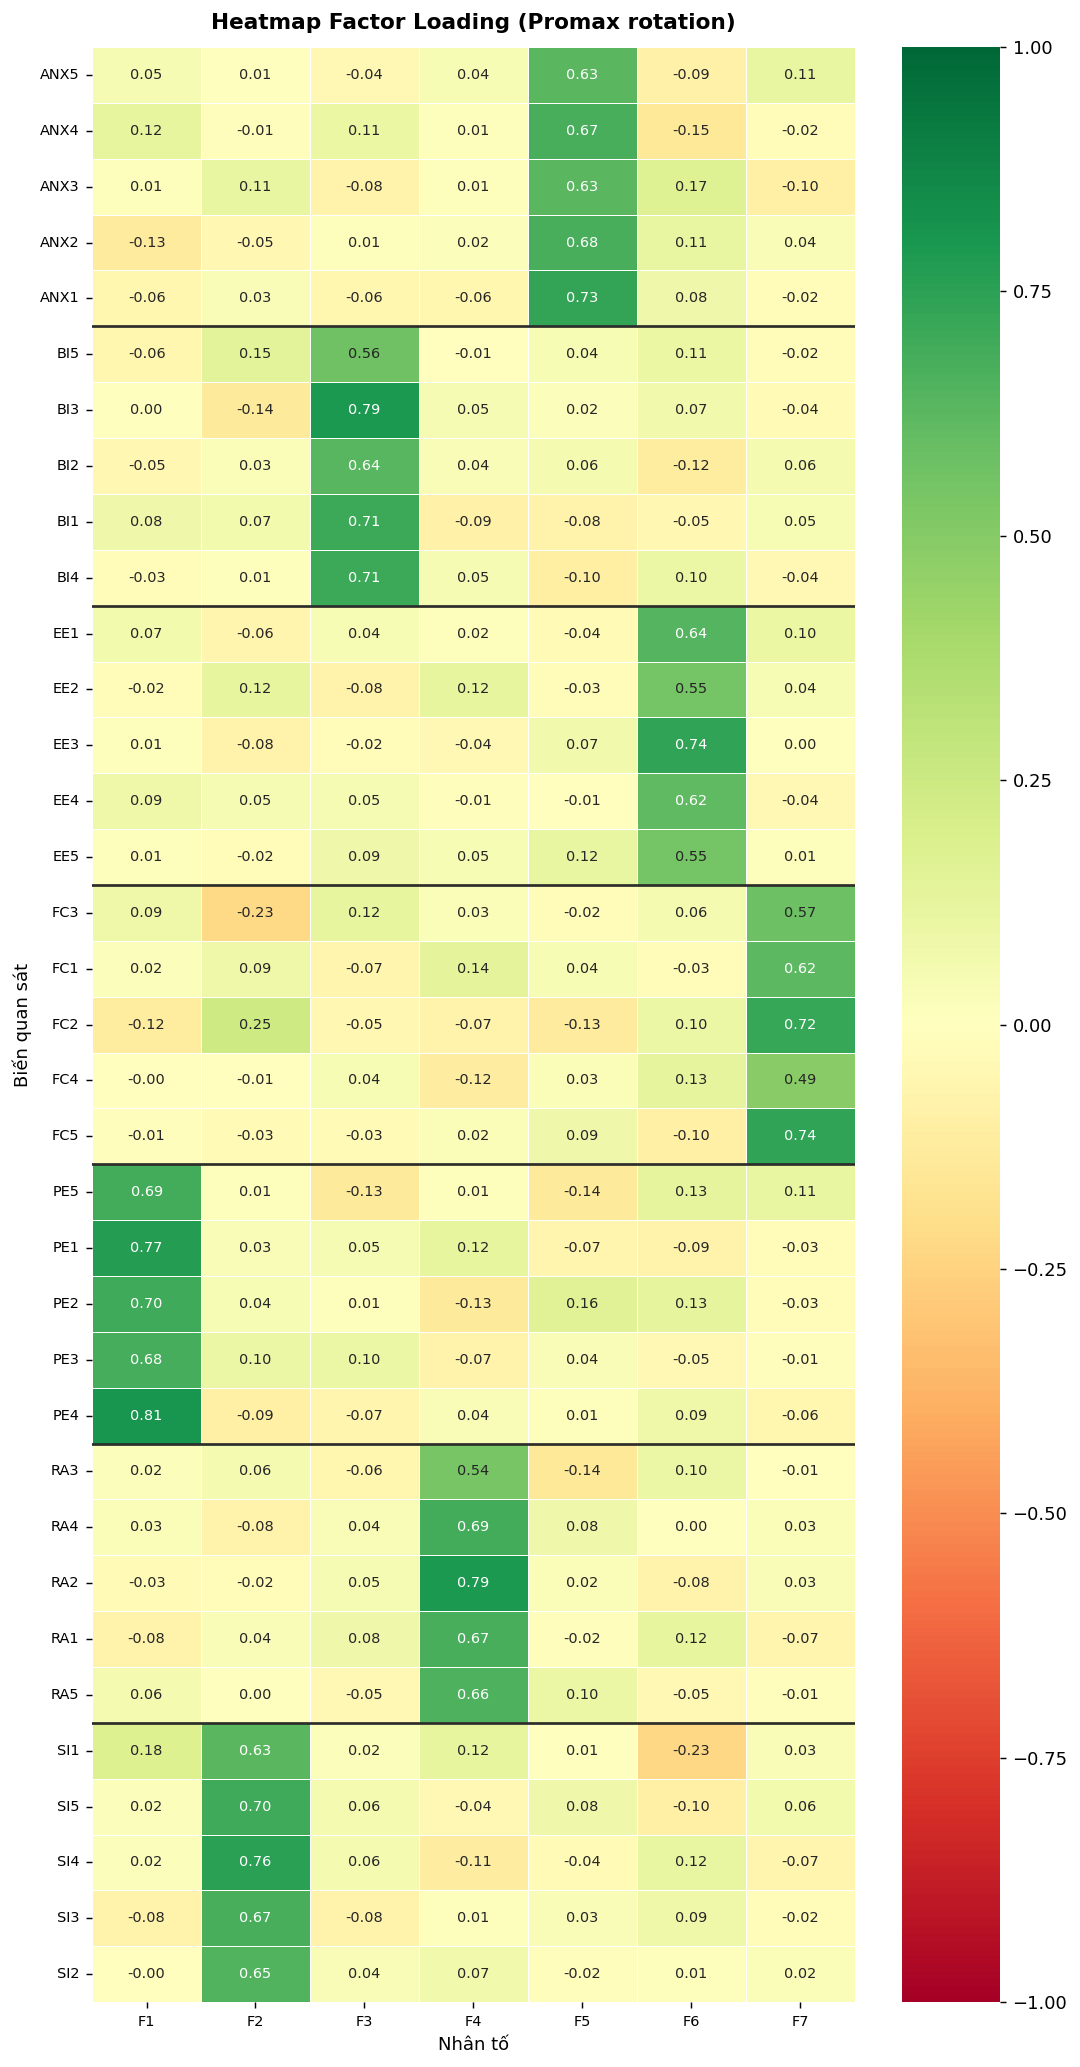

In [8]:
# Sắp xếp item theo nhóm lý thuyết cho dễ đọc
df_load_sorted = df_load.sort_values('Nhóm lý thuyết')
load_matrix    = df_load_sorted[factor_cols]

fig, ax = plt.subplots(figsize=(max(8, N_FACTORS*1.2), len(likert_cols)*0.4 + 2))

sns.heatmap(
    load_matrix, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    linewidths=0.4, linecolor='white',
    annot_kws={'size': 8},
    ax=ax
)
ax.set_title('Heatmap Factor Loading (Promax rotation)',
             fontweight='bold', fontsize=12, pad=10)
ax.set_xlabel('Nhân tố', fontsize=10)
ax.set_ylabel('Biến quan sát', fontsize=10)
ax.tick_params(axis='both', labelsize=8)

# Đường kẻ phân nhóm lý thuyết
current_group = None
boundary_rows = []
for i, item in enumerate(df_load_sorted.index):
    g = df_load_sorted.loc[item, 'Nhóm lý thuyết']
    if g != current_group:
        if i > 0: boundary_rows.append(i)
        current_group = g
for br in boundary_rows:
    ax.axhline(br, color='#2C2C2A', linewidth=1.5)

plt.tight_layout()
plt.savefig('efa_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Kết luận & xuất file

In [9]:
var_exp   = fa.get_factor_variance()
total_pct = var_exp[2][-1] * 100

print('=== KẾT LUẬN EFA ===')
print(f'  KMO           : {kmo_model:.4f}')
print(f'  Bartlett p    : {p_val:.4f}')
print(f'  Số nhân tố    : {N_FACTORS}')
print(f'  Tổng phương sai: {total_pct:.2f}%')
print(f'  Item có vấn đề : {items_issue if items_issue else "Không có"}')

print('\n→ Bước tiếp theo: CFA trên AMOS')
print('   Xuất data_sau_efa.csv để nhập SPSS/AMOS')

=== KẾT LUẬN EFA ===
  KMO           : 0.8610
  Bartlett p    : 0.0000
  Số nhân tố    : 7
  Tổng phương sai: 48.87%
  Item có vấn đề : ['EE1', 'EE2', 'EE4', 'EE5', 'PE3', 'SI1', 'SI2', 'SI3', 'FC1', 'FC3', 'FC4', 'RA1', 'RA3', 'RA4', 'RA5', 'ANX2', 'ANX3', 'ANX5', 'BI2', 'BI5']

→ Bước tiếp theo: CFA trên AMOS
   Xuất data_sau_efa.csv để nhập SPSS/AMOS


In [10]:
# Xuất file
df.to_csv('data_sau_efa.csv', index=False, encoding='utf-8-sig')

with pd.ExcelWriter('efa_results.xlsx', engine='openpyxl') as writer:
    df_load.round(4).to_excel(writer, sheet_name='Factor_Loading')
    pd.DataFrame({
        'Factor': factor_cols,
        'SS Loadings':     [round(v,4) for v in var_exp[0]],
        'Proportion Var':  [round(v,4) for v in var_exp[1]],
        'Cumulative Var':  [round(v,4) for v in var_exp[2]],
    }).to_excel(writer, sheet_name='Variance_Explained', index=False)
    pd.DataFrame({'Item': likert_cols, 'KMO': kmo_all}).to_excel(
        writer, sheet_name='KMO_per_item', index=False)

for f in ['efa_results.xlsx', 'data_sau_efa.csv', 'scree_plot.png', 'efa_heatmap.png']:
    files.download(f)

print('Download xong!')
print('\nBước tiếp theo → CFA & SEM trên AMOS (dùng data_sau_efa.csv)')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download xong!

Bước tiếp theo → CFA & SEM trên AMOS (dùng data_sau_efa.csv)
